In [2]:
from src.rttpc.pipeline import *
from src.rttpc.utils import *

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
# Pre-load models and prepare other stuff

camera_intrinsics = [2813.643275, 2808.326079, 969.285772, 624.049972]

T_cam2lidar = np.eye(4)
T_cam2lidar[0:3,0:3] = quaternion_to_rotation_matrix([-0.50507811, 0.51206185, 0.49024953, -0.49228464])
T_cam2lidar[0,3] = -0.13165462
T_cam2lidar[1,3] = 0.03870398
T_cam2lidar[2,3] = -0.17253834

T_lidar2base = np.diag([-1.0, 1.0, -1.0, 1.0])
T_cam2base = T_lidar2base @ T_cam2lidar

trav_map = TraversabilityMap(
    h = 96,
    w = 96,
    offset_x = -48, # 0 at map center
    offset_y = -48, # 0 at map center
    resolution= 0.10,
    decay_time=3.0
)

positive_queries = [
    "a photo of a flat clear road",
    "a photo of a walkable dirt path",
    "a photo of flat grassy ground",
]

negative_queries = [
    "a photo of the sky",
    "a photo of a wall",
    "a photo of deep water",
    "a photo of a puddle",
    "a photo of a tree",
    "a photo of trees",
    "a photo of a large rock",
    "a photo of a person",
    "a photo of a cliff",
    "a photo of a bush"
]

sam_model, sam_processor, sam_device = load_sam_model()

clip_model, clip_processor, clip_device = load_clip_model()

da_model, da_processor, da_device = load_da_model() # Maybe want to load both indoor and outdoor models and use CLIP to select which one to use

# Pre-process queries for faster scoring (shaves off roughly 1 second of processing time per image)
safety_embeddings, trav_embeddings = prepare_text_embeddings(positive_queries, negative_queries, clip_model, clip_processor, clip_device)

logger.info(f"All models loaded.")

2026-10-09 18:09:33,383 [INFO] rttpc.load_models: Loading SAM model: facebook/sam-vit-base...
2026-10-09 18:09:33,564 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
2026-10-09 18:09:33,712 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/facebook/sam-vit-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-10-09 18:09:33,861 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/sam-vit-base/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-10-09 18:09:34,009 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/sam-vit-base/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
2026-10-09 18:09:34,154 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/sam-vit-base/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
2026-10-09 18:09:34,300 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/sam-vit-base/reso

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

2026-10-09 18:09:36,574 [INFO] rttpc.load_models: SAM model loaded on device: cuda
2026-10-09 18:09:36,575 [INFO] rttpc.load_models: Loading CLIP model: openai/clip-vit-base-patch32...
2026-10-09 18:09:36,729 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-10-09 18:09:36,901 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-10-09 18:09:37,064 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
2026-10-09 18:09:37,204 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
2026-10-09 18:09:37,347 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-pat

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

2026-10-09 18:09:40,844 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32 "HTTP/1.1 200 OK"
2026-10-09 18:09:40,996 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/main "HTTP/1.1 200 OK"
2026-10-09 18:09:41,165 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/discussions?p=0 "HTTP/1.1 200 OK"
2026-10-09 18:09:41,312 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/refs%2Fpr%2F66 "HTTP/1.1 200 OK"
2026-10-09 18:09:41,472 [INFO] rttpc.load_models: CLIP model loaded on device: cuda
2026-10-09 18:09:41,472 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-10-09 18:09:41,473 [INFO] rttpc.load_models: Loading DepthAnything model: depth-anything/Depth-Anything-V2-Metric-Outdoor-Sma

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

2026-10-09 18:09:42,545 [INFO] rttpc.load_models: DepthAnything model loaded on device: cuda
2026-10-09 18:09:43,197 [INFO] src.rttpc.pipeline: All models loaded.


2026-10-09 18:53:04,555 [INFO] src.rttpc.pipeline: DepthAnything processing time: 0.8390s
2026-10-09 18:53:04,556 [INFO] src.rttpc.pipeline: Generating SAM proposals with 6x6 grid...
2026-10-09 18:53:04,857 [INFO] src.rttpc.pipeline: Generated 8 unique segment proposals
2026-10-09 18:53:04,858 [INFO] src.rttpc.pipeline: SAM processing time: 0.3028s
2026-10-09 18:53:05,091 [INFO] src.rttpc.pipeline: CLIP processing time: 0.2334s (avg 0.0292s per segment)
2026-10-09 18:53:05,092 [INFO] src.rttpc.pipeline: Total processing time: 1.3752s
2026-10-09 18:53:05,092 [INFO] src.rttpc.pipeline: Visualizing results...


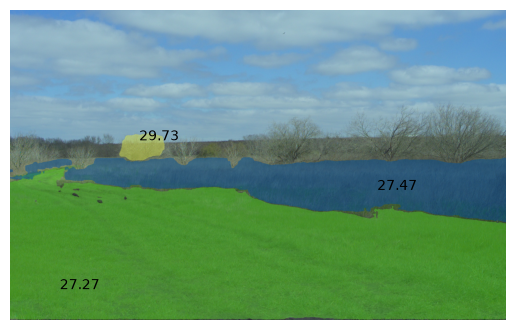

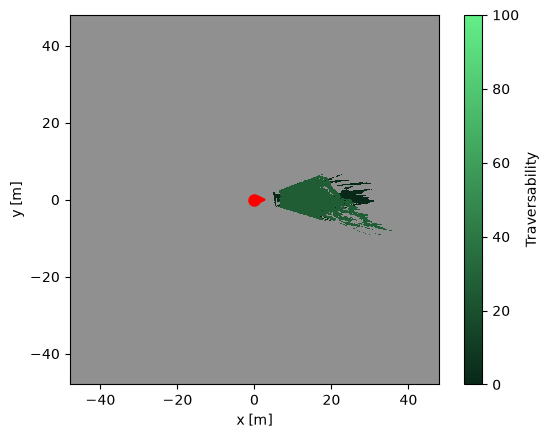

2026-10-09 18:53:06,537 [INFO] src.rttpc.pipeline: DepthAnything processing time: 0.3358s
2026-10-09 18:53:06,538 [INFO] src.rttpc.pipeline: Generating SAM proposals with 6x6 grid...
2026-10-09 18:53:06,831 [INFO] src.rttpc.pipeline: Generated 9 unique segment proposals
2026-10-09 18:53:06,832 [INFO] src.rttpc.pipeline: SAM processing time: 0.2945s
2026-10-09 18:53:07,087 [INFO] src.rttpc.pipeline: CLIP processing time: 0.2553s (avg 0.0284s per segment)
2026-10-09 18:53:07,088 [INFO] src.rttpc.pipeline: Total processing time: 0.8856s
2026-10-09 18:53:07,088 [INFO] src.rttpc.pipeline: Visualizing results...


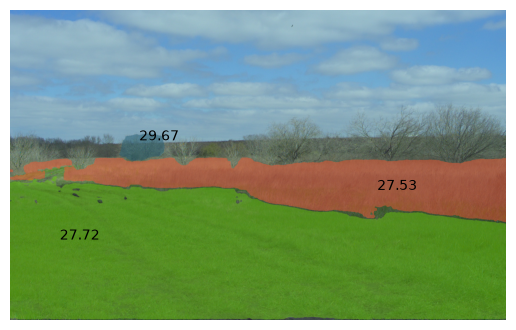

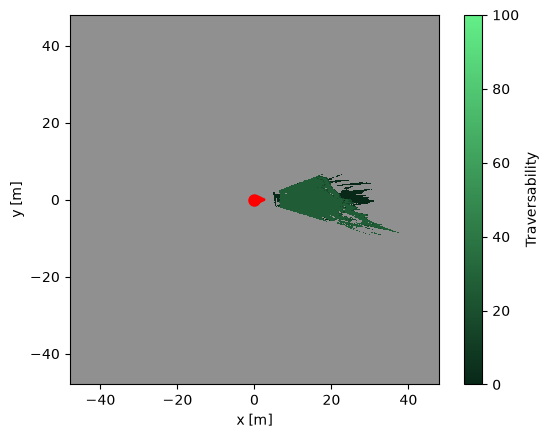

2026-10-09 18:53:08,426 [INFO] src.rttpc.pipeline: DepthAnything processing time: 0.3197s
2026-10-09 18:53:08,427 [INFO] src.rttpc.pipeline: Generating SAM proposals with 6x6 grid...
2026-10-09 18:53:08,739 [INFO] src.rttpc.pipeline: Generated 8 unique segment proposals
2026-10-09 18:53:08,740 [INFO] src.rttpc.pipeline: SAM processing time: 0.3139s
2026-10-09 18:53:08,963 [INFO] src.rttpc.pipeline: CLIP processing time: 0.2230s (avg 0.0279s per segment)
2026-10-09 18:53:08,964 [INFO] src.rttpc.pipeline: Total processing time: 0.8566s
2026-10-09 18:53:08,964 [INFO] src.rttpc.pipeline: Visualizing results...


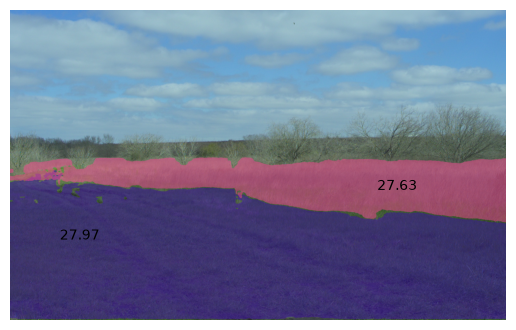

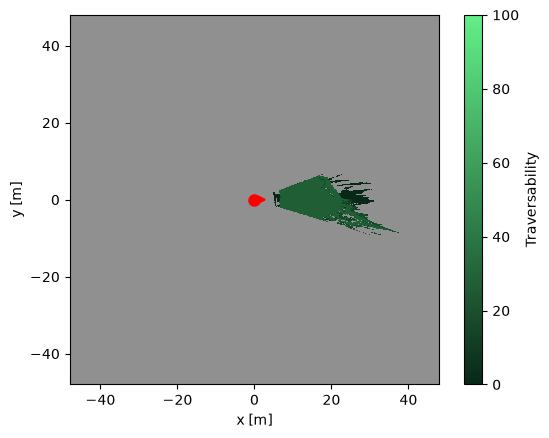

2026-10-09 18:53:10,091 [INFO] src.rttpc.pipeline: DepthAnything processing time: 0.3193s
2026-10-09 18:53:10,092 [INFO] src.rttpc.pipeline: Generating SAM proposals with 6x6 grid...
2026-10-09 18:53:10,374 [INFO] src.rttpc.pipeline: Generated 7 unique segment proposals
2026-10-09 18:53:10,375 [INFO] src.rttpc.pipeline: SAM processing time: 0.2839s
2026-10-09 18:53:10,581 [INFO] src.rttpc.pipeline: CLIP processing time: 0.2060s (avg 0.0294s per segment)
2026-10-09 18:53:10,582 [INFO] src.rttpc.pipeline: Total processing time: 0.8093s
2026-10-09 18:53:10,582 [INFO] src.rttpc.pipeline: Visualizing results...


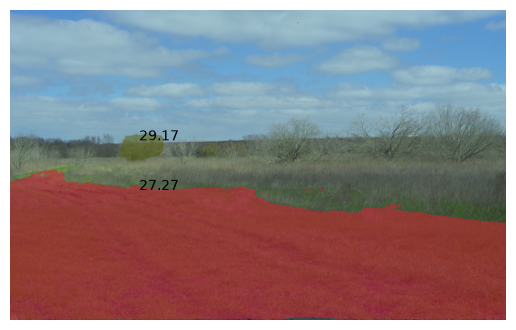

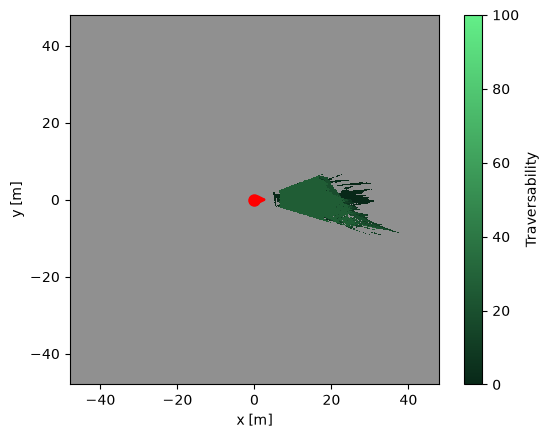

2026-10-09 18:53:11,725 [INFO] src.rttpc.pipeline: DepthAnything processing time: 0.3223s
2026-10-09 18:53:11,726 [INFO] src.rttpc.pipeline: Generating SAM proposals with 6x6 grid...
2026-10-09 18:53:12,032 [INFO] src.rttpc.pipeline: Generated 9 unique segment proposals
2026-10-09 18:53:12,033 [INFO] src.rttpc.pipeline: SAM processing time: 0.3072s
2026-10-09 18:53:12,288 [INFO] src.rttpc.pipeline: CLIP processing time: 0.2558s (avg 0.0284s per segment)
2026-10-09 18:53:12,289 [INFO] src.rttpc.pipeline: Total processing time: 0.8854s
2026-10-09 18:53:12,289 [INFO] src.rttpc.pipeline: Visualizing results...


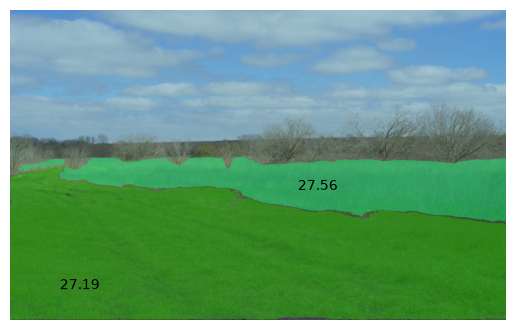

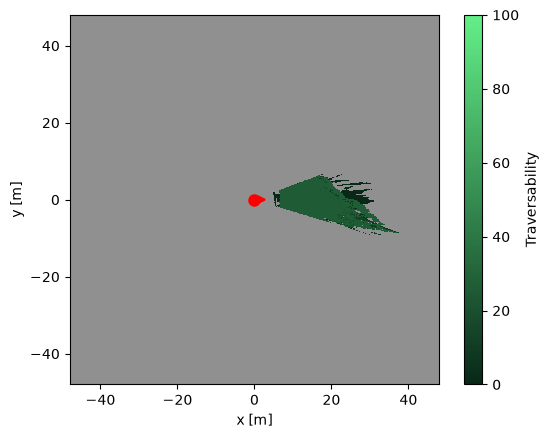

2026-10-09 18:53:13,390 [INFO] src.rttpc.pipeline: DepthAnything processing time: 0.3200s
2026-10-09 18:53:13,391 [INFO] src.rttpc.pipeline: Generating SAM proposals with 6x6 grid...
2026-10-09 18:53:13,684 [INFO] src.rttpc.pipeline: Generated 8 unique segment proposals
2026-10-09 18:53:13,685 [INFO] src.rttpc.pipeline: SAM processing time: 0.2951s
2026-10-09 18:53:13,917 [INFO] src.rttpc.pipeline: CLIP processing time: 0.2315s (avg 0.0289s per segment)
2026-10-09 18:53:13,917 [INFO] src.rttpc.pipeline: Total processing time: 0.8466s
2026-10-09 18:53:13,917 [INFO] src.rttpc.pipeline: Visualizing results...


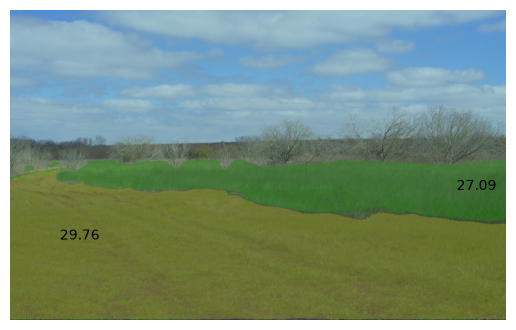

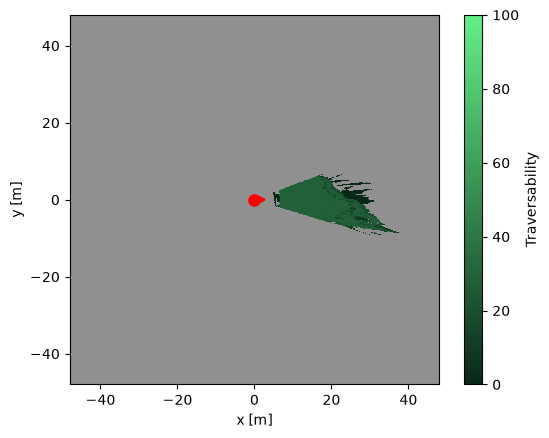

2026-10-09 18:53:15,050 [INFO] src.rttpc.pipeline: DepthAnything processing time: 0.3459s
2026-10-09 18:53:15,050 [INFO] src.rttpc.pipeline: Generating SAM proposals with 6x6 grid...
2026-10-09 18:53:15,334 [INFO] src.rttpc.pipeline: Generated 8 unique segment proposals
2026-10-09 18:53:15,337 [INFO] src.rttpc.pipeline: SAM processing time: 0.2871s
2026-10-09 18:53:15,455 [INFO] src.rttpc.pipeline: CLIP processing time: 0.1184s (avg 0.0148s per segment)
2026-10-09 18:53:15,456 [INFO] src.rttpc.pipeline: Total processing time: 0.7514s
2026-10-09 18:53:15,456 [INFO] src.rttpc.pipeline: Visualizing results...


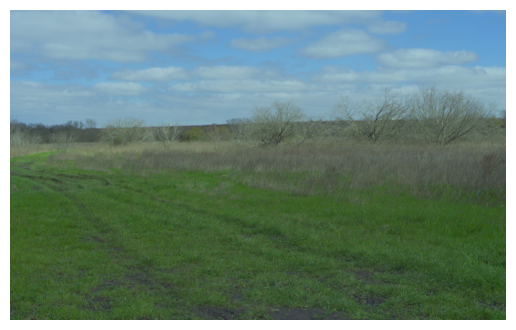

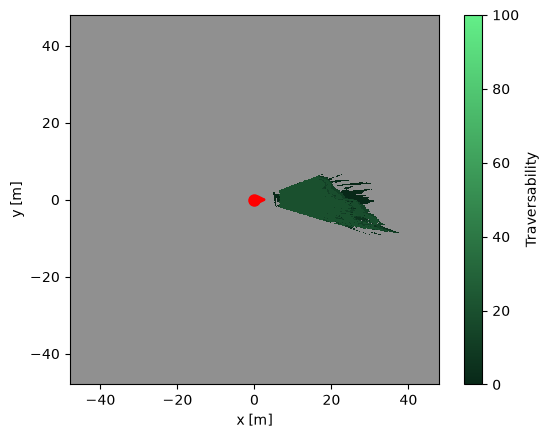

2026-10-09 18:53:16,067 [INFO] src.rttpc.pipeline: DepthAnything processing time: 0.3185s
2026-10-09 18:53:16,067 [INFO] src.rttpc.pipeline: Generating SAM proposals with 6x6 grid...
2026-10-09 18:53:16,357 [INFO] src.rttpc.pipeline: Generated 6 unique segment proposals
2026-10-09 18:53:16,358 [INFO] src.rttpc.pipeline: SAM processing time: 0.2916s
2026-10-09 18:53:16,455 [INFO] src.rttpc.pipeline: CLIP processing time: 0.0966s (avg 0.0161s per segment)
2026-10-09 18:53:16,455 [INFO] src.rttpc.pipeline: Total processing time: 0.7067s
2026-10-09 18:53:16,456 [INFO] src.rttpc.pipeline: Visualizing results...


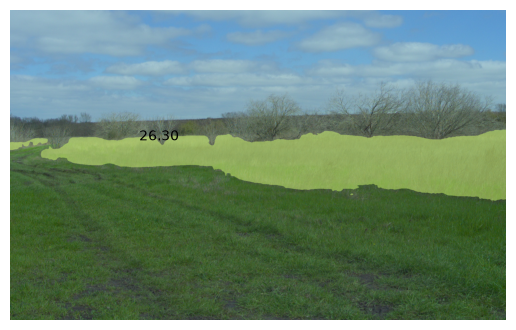

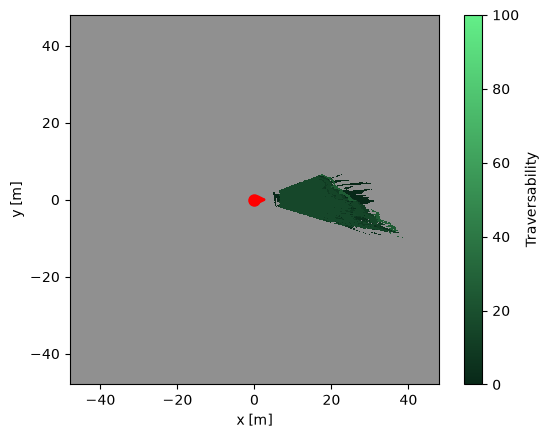

2026-10-09 18:53:17,252 [INFO] src.rttpc.pipeline: DepthAnything processing time: 0.2970s
2026-10-09 18:53:17,252 [INFO] src.rttpc.pipeline: Generating SAM proposals with 6x6 grid...
2026-10-09 18:53:17,529 [INFO] src.rttpc.pipeline: Generated 8 unique segment proposals
2026-10-09 18:53:17,530 [INFO] src.rttpc.pipeline: SAM processing time: 0.2785s
2026-10-09 18:53:17,641 [INFO] src.rttpc.pipeline: CLIP processing time: 0.1111s (avg 0.0139s per segment)
2026-10-09 18:53:17,642 [INFO] src.rttpc.pipeline: Total processing time: 0.6865s
2026-10-09 18:53:17,642 [INFO] src.rttpc.pipeline: Visualizing results...


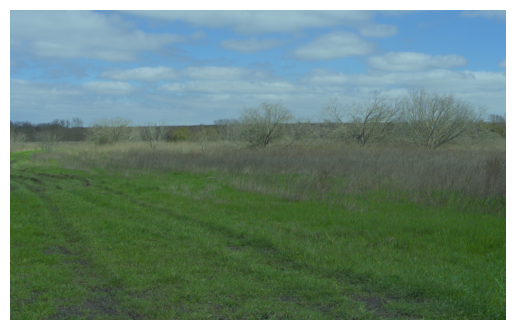

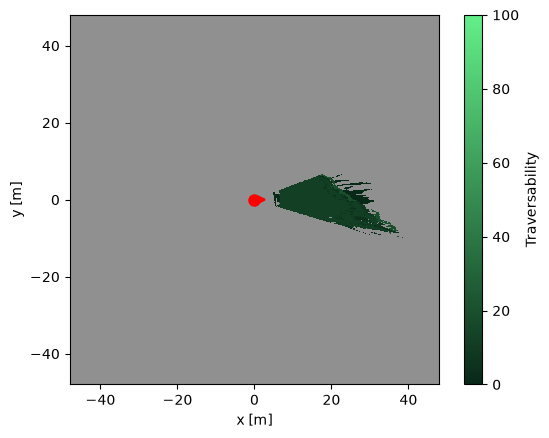

2026-10-09 18:53:18,277 [INFO] src.rttpc.pipeline: DepthAnything processing time: 0.3299s
2026-10-09 18:53:18,278 [INFO] src.rttpc.pipeline: Generating SAM proposals with 6x6 grid...
2026-10-09 18:53:18,558 [INFO] src.rttpc.pipeline: Generated 8 unique segment proposals
2026-10-09 18:53:18,561 [INFO] src.rttpc.pipeline: SAM processing time: 0.2836s
2026-10-09 18:53:18,680 [INFO] src.rttpc.pipeline: CLIP processing time: 0.1190s (avg 0.0149s per segment)
2026-10-09 18:53:18,680 [INFO] src.rttpc.pipeline: Total processing time: 0.7325s
2026-10-09 18:53:18,681 [INFO] src.rttpc.pipeline: Visualizing results...


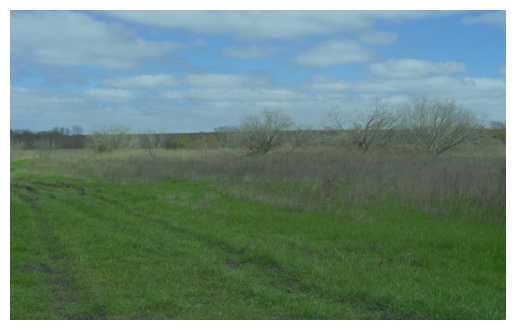

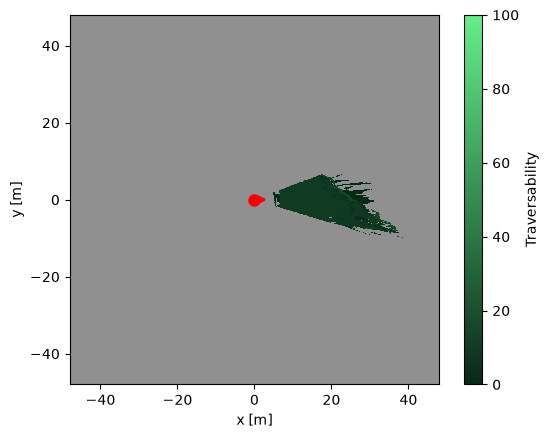

2026-10-09 18:53:19,319 [INFO] src.rttpc.pipeline: DepthAnything processing time: 0.3384s
2026-10-09 18:53:19,320 [INFO] src.rttpc.pipeline: Generating SAM proposals with 6x6 grid...
2026-10-09 18:53:19,609 [INFO] src.rttpc.pipeline: Generated 11 unique segment proposals
2026-10-09 18:53:19,610 [INFO] src.rttpc.pipeline: SAM processing time: 0.2912s
2026-10-09 18:53:19,871 [INFO] src.rttpc.pipeline: CLIP processing time: 0.2606s (avg 0.0237s per segment)
2026-10-09 18:53:19,871 [INFO] src.rttpc.pipeline: Total processing time: 0.8902s
2026-10-09 18:53:19,872 [INFO] src.rttpc.pipeline: Visualizing results...


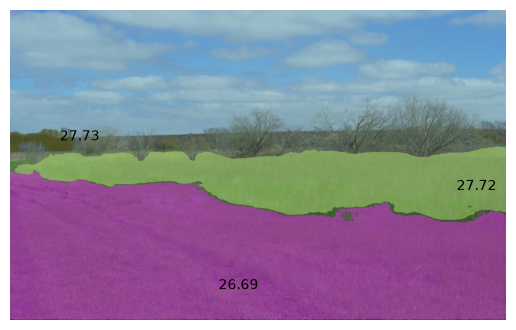

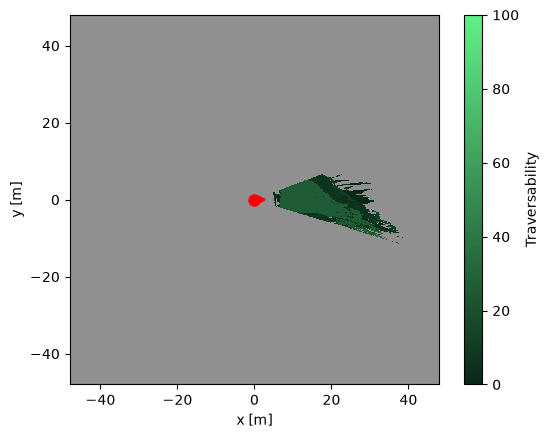

2026-10-09 18:53:21,278 [INFO] src.rttpc.pipeline: DepthAnything processing time: 0.3623s
2026-10-09 18:53:21,279 [INFO] src.rttpc.pipeline: Generating SAM proposals with 6x6 grid...
2026-10-09 18:53:21,556 [INFO] src.rttpc.pipeline: Generated 5 unique segment proposals
2026-10-09 18:53:21,557 [INFO] src.rttpc.pipeline: SAM processing time: 0.2794s
2026-10-09 18:53:21,635 [INFO] src.rttpc.pipeline: CLIP processing time: 0.0775s (avg 0.0155s per segment)
2026-10-09 18:53:21,635 [INFO] src.rttpc.pipeline: Total processing time: 0.7193s
2026-10-09 18:53:21,636 [INFO] src.rttpc.pipeline: Visualizing results...


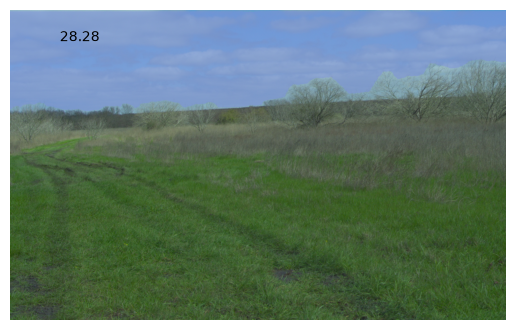

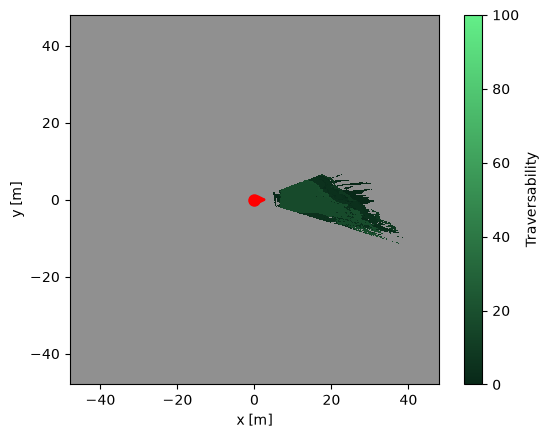

2026-10-09 18:53:22,506 [INFO] src.rttpc.pipeline: DepthAnything processing time: 0.3424s
2026-10-09 18:53:22,507 [INFO] src.rttpc.pipeline: Generating SAM proposals with 6x6 grid...
2026-10-09 18:53:22,812 [INFO] src.rttpc.pipeline: Generated 6 unique segment proposals
2026-10-09 18:53:22,813 [INFO] src.rttpc.pipeline: SAM processing time: 0.3069s
2026-10-09 18:53:22,911 [INFO] src.rttpc.pipeline: CLIP processing time: 0.0980s (avg 0.0163s per segment)
2026-10-09 18:53:22,912 [INFO] src.rttpc.pipeline: Total processing time: 0.7473s
2026-10-09 18:53:22,912 [INFO] src.rttpc.pipeline: Visualizing results...


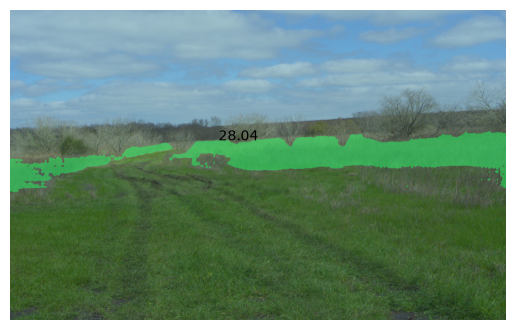

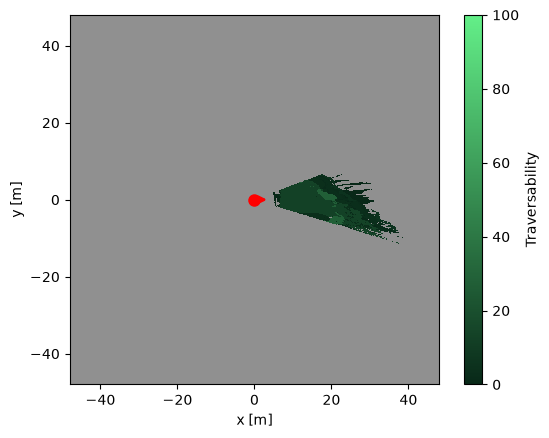

2026-10-09 18:53:23,795 [INFO] src.rttpc.pipeline: DepthAnything processing time: 0.3469s
2026-10-09 18:53:23,796 [INFO] src.rttpc.pipeline: Generating SAM proposals with 6x6 grid...
2026-10-09 18:53:24,081 [INFO] src.rttpc.pipeline: Generated 6 unique segment proposals
2026-10-09 18:53:24,082 [INFO] src.rttpc.pipeline: SAM processing time: 0.2869s
2026-10-09 18:53:24,181 [INFO] src.rttpc.pipeline: CLIP processing time: 0.0992s (avg 0.0165s per segment)
2026-10-09 18:53:24,182 [INFO] src.rttpc.pipeline: Total processing time: 0.7330s
2026-10-09 18:53:24,182 [INFO] src.rttpc.pipeline: Visualizing results...


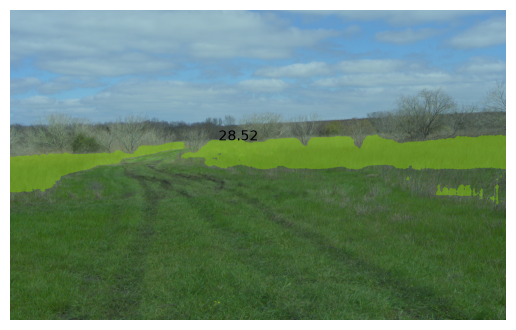

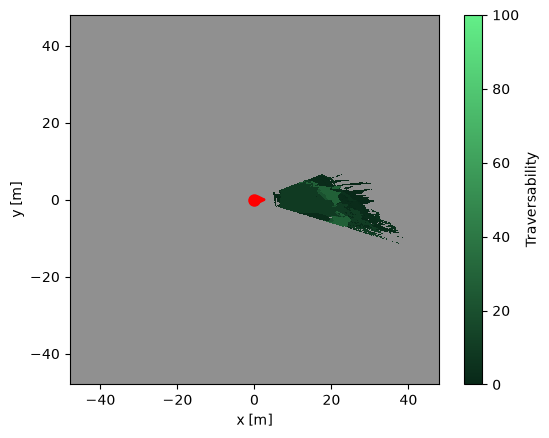

2026-10-09 18:53:25,053 [INFO] src.rttpc.pipeline: DepthAnything processing time: 0.3612s
2026-10-09 18:53:25,054 [INFO] src.rttpc.pipeline: Generating SAM proposals with 6x6 grid...
2026-10-09 18:53:25,334 [INFO] src.rttpc.pipeline: Generated 4 unique segment proposals
2026-10-09 18:53:25,335 [INFO] src.rttpc.pipeline: SAM processing time: 0.2814s
2026-10-09 18:53:25,395 [INFO] src.rttpc.pipeline: CLIP processing time: 0.0609s (avg 0.0152s per segment)
2026-10-09 18:53:25,396 [INFO] src.rttpc.pipeline: Total processing time: 0.7035s
2026-10-09 18:53:25,396 [INFO] src.rttpc.pipeline: Visualizing results...


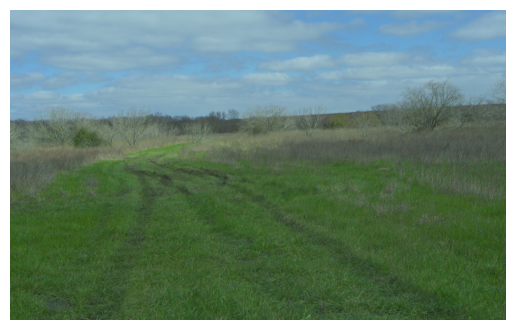

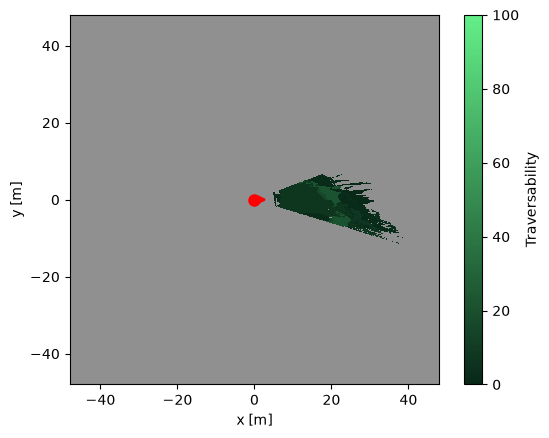

In [7]:
for image, T_base2map, img_path in rellis3d_frames(session=1,start=0,stride=10,end=150):

    # Depth time :)
    start_processing_time = time.perf_counter()

    depth = get_image_depth(image, da_model, da_processor, da_device)

    pcd, pixel_indices = image_to_world(image, depth, camera_intrinsics)

    # Fit only nearby points in the bottom half of the image to avoid sky.
    ground_fit_min_row = 0.5 * image.height
    ground_fit_max_depth = 20.0  # metres (camera z)
    fit_mask = (
        (pixel_indices // image.width >= ground_fit_min_row)
        & (np.asarray(pcd.points)[:, 2] <= ground_fit_max_depth)
    )
    plane = get_ground_plane(pcd.select_by_index(np.flatnonzero(fit_mask)))
        
    ground_indices = gather_ground_indices(pcd, plane)

    end_da_processing_time = time.perf_counter()

    logger.info(f"DepthAnything processing time: {(end_da_processing_time-start_processing_time):.4f}s")

    # SAM time :D
    segmentations = generate_sam_masks(image, sam_model, sam_processor, sam_device)

    end_SAM_processing_time = time.perf_counter()
    logger.info(f"SAM processing time: {(end_SAM_processing_time-end_da_processing_time):.4f}s")

    viz_pcd = open3d.geometry.PointCloud()
    for segment in segmentations:
        mask = segment["mask"]

        segment["trav_score"] = 100 * score_with_clip(image, mask, clip_model, clip_processor, clip_device, safety_embeddings, trav_embeddings)
        #visualize_segment_scores([segment], image)

        if segment["trav_score"] is not None:
            # Sample the image mask at each ground point's source pixel, then
            # retain the corresponding indices into the original cloud.
            keep = mask.ravel()[pixel_indices[ground_indices]]
            trav_indices = ground_indices[keep]
            trav_pcd = pcd.select_by_index(trav_indices)
            # Transform trav_pcd into world frame (skipped for now, robot->world will be defined later)
            points_world = trav_pcd.transform(T_cam2base)
            map_indices = world_coords_to_map_indices(np.asarray(points_world.points), trav_map)
            # Right now, we just overwrite cells directly. Realistically, I'd rather add the scores to already existing scores to increase the confidence,
            # since multiple observations should make us more confident. 
            trav_map[map_indices] = segment["trav_score"]

            viz_pcd.points.extend(points_world.points)

    end_CLIP_processing_time = time.perf_counter()
    logger.info(f"CLIP processing time: {(end_CLIP_processing_time-end_SAM_processing_time):.4f}s (avg {(end_CLIP_processing_time-end_SAM_processing_time)/len(segmentations):.4f}s per segment)")

    logger.info(f"Total processing time: {(end_CLIP_processing_time-start_processing_time):.4f}s")

    logger.info("Visualizing results...")
    #visualize_segment_scores(segmentations, image)
    visualize_traversable_segments(segmentations, image)
    # open3d.visualization.draw_geometries([pcd.transform(T_cam2base), viz_pcd.paint_uniform_color([0,1,0])])

    pose = (0,0,0)
    show_traversability(trav_map, pose)